In [1]:
import matplotlib.pyplot as plt
import torch 
import torch.nn.functional as f
char_dim=10
bloc_size=3
nb_ite=100000
hidden_layer=100
batch_size=32
vocab_size=27
lr=0.1

In [2]:
words=open("names.txt",'r').read().splitlines()
index_chars={i+1:chr(i+ord("a")) for i in range (26)}
index_chars[0]='.'
chars_index={i:s for s,i in index_chars.items()}
def build_data(words,bloc_size):
    X,Y=[],[]
    for w in words:
        sample=[0]*bloc_size
        for ch in w + ".":
            ix=chars_index[ch]
            X.append(sample)
            Y.append(ix)
            sample=sample[1:]+[ix]
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    return(X,Y)
import random 
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
Xtr,Ytr=build_data(words[:n1],bloc_size)
Xdev,Ydev=build_data(words[n1:n2],bloc_size)
Xte,Yte=build_data(words[n2:],bloc_size)

In [3]:
g = torch.Generator().manual_seed(2147483647)
class Linear:
    def __init__(self,n_input,n_output,bias=True):
        self.weight=torch.randn((n_input,n_output),generator=g)/n_input**0.5
        if bias==True:
            self.bias=torch.zeros(n_output)
        else:
            self.bias=None
    def __call__(self,x_input):
        self.out=x_input@self.weight
        if self.bias != None:
            self.out+=self.bias
        return(self.out)
    def parameters(self):
        if self.bias==None:
            return([self.weight])
        else:
            return([self.weight]+[self.bias])
class BatchNorm1d:
    def __init__(self,dim,eps=1e-5,momentum=0.1,train=True):
        self.eps=eps
        self.momentum=momentum
        self.training=train
        self.gamma=torch.ones(dim)
        self.beta=torch.zeros(dim)
        self.running_mean=torch.zeros(dim)
        self.running_var=torch.ones(dim)
    def __call__(self,x):
        if self.training:
            xmean=x.mean(0,keepdim=True)
            xvar=x.var(0,keepdim=True)
        else:
            xmean=self.running_mean
            xvar=self.running_var
        x_norm=(x-xmean)/((xvar+self.eps)**0.5)
        self.out=self.gamma*x_norm+self.beta
        if self.training==True:
            self.running_mean=self.running_mean*(1-self.momentum)+xmean*self.momentum
            self.running_var=self.running_var*(1-self.momentum)+xvar*self.momentum
        return self.out
    def parameters(self):
        return [self.gamma,self.beta]
class Tanh:
    def __call__(self,x):
        self.out=torch.tanh(x)
        return self.out
    def parameters(self):
        return []


In [4]:
C=torch.randn((27,char_dim))
layers = [
  Linear(char_dim * bloc_size, hidden_layer, bias=False), BatchNorm1d(hidden_layer), Tanh(),
  Linear(           hidden_layer, hidden_layer, bias=False), BatchNorm1d(hidden_layer), Tanh(),
  Linear(           hidden_layer, hidden_layer, bias=False), BatchNorm1d(hidden_layer), Tanh(),
  Linear(           hidden_layer, hidden_layer, bias=False), BatchNorm1d(hidden_layer), Tanh(),
  Linear(           hidden_layer, hidden_layer, bias=False), BatchNorm1d(hidden_layer), Tanh(),
  Linear(           hidden_layer, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
with torch.no_grad():
  layers[-1].gamma *= 0.1
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 5/3
parameters=[C]+[p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad=True

In [5]:
lre=torch.linspace(-3,0,1000)
lrs=10**lre
lossi,stepi=[],[]
ud=[]
for i in range(nb_ite+1):
    ix=torch.randint(0,Xtr.shape[0],(batch_size,))
    xb,yb=Xtr[ix],Ytr[ix]
    emb=C[xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)
    loss=f.cross_entropy(x,yb)
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad=None
    loss.backward()    
    if i>nb_ite//2:
        lr=lr/10
    for p in parameters:
        p.data+=-lr*p.grad
    lossi.append(loss.log10().item())
    stepi.append(i)
    if i%10000==0:
        print(i,":",loss.item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break


0 : 3.290303945541382


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.75%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.59%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.25%
layer 11 (      Tanh): mean +0.00, std 0.64, saturated: 2.41%
layer 14 (      Tanh): mean +0.00, std 0.64, saturated: 2.34%


C:\Users\sabri\AppData\Local\Temp\ipykernel_19860\1294834595.py:6: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

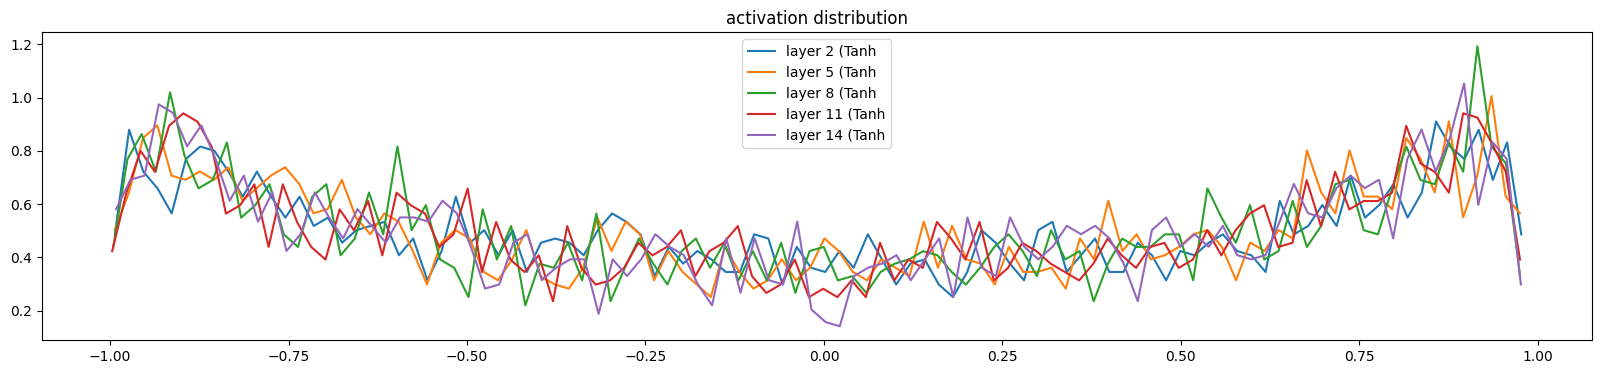

In [6]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 3.724901e-03
layer 5 (      Tanh): mean -0.000000, std 3.210230e-03
layer 8 (      Tanh): mean -0.000000, std 2.962299e-03
layer 11 (      Tanh): mean +0.000000, std 2.623273e-03
layer 14 (      Tanh): mean +0.000000, std 2.535937e-03


Text(0.5, 1.0, 'gradient distribution')

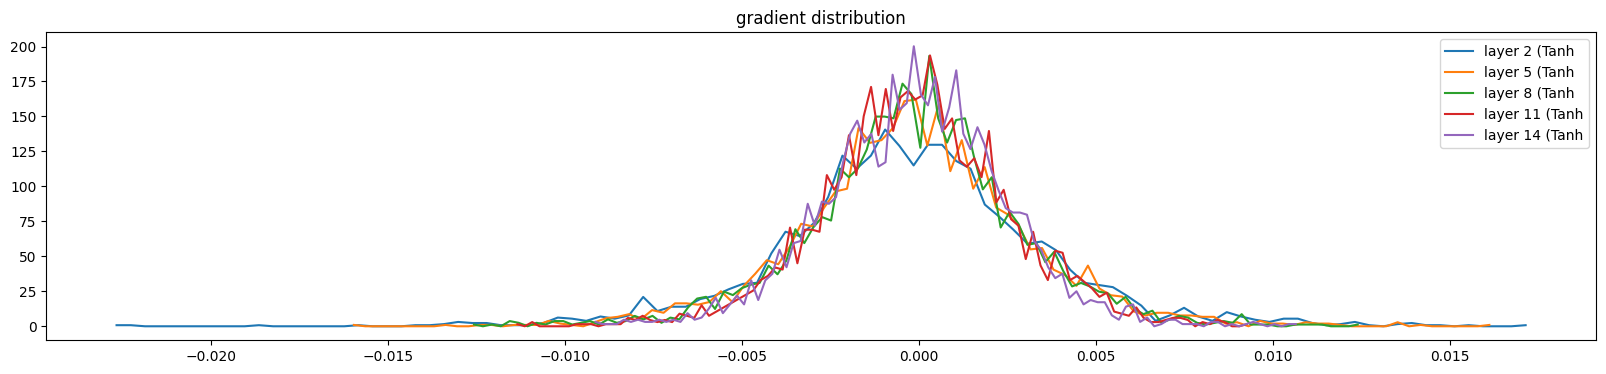

In [7]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 1.051807e-02 | grad:data ratio 1.018007e-02
weight  (30, 100) | mean +0.000011 | std 9.436713e-03 | grad:data ratio 3.060114e-02
weight (100, 100) | mean +0.000018 | std 7.357867e-03 | grad:data ratio 4.376680e-02
weight (100, 100) | mean -0.000047 | std 6.497105e-03 | grad:data ratio 3.881648e-02
weight (100, 100) | mean -0.000017 | std 5.495045e-03 | grad:data ratio 3.279280e-02
weight (100, 100) | mean -0.000020 | std 5.196825e-03 | grad:data ratio 3.081642e-02
weight  (100, 27) | mean +0.000236 | std 9.659682e-03 | grad:data ratio 5.804595e-02


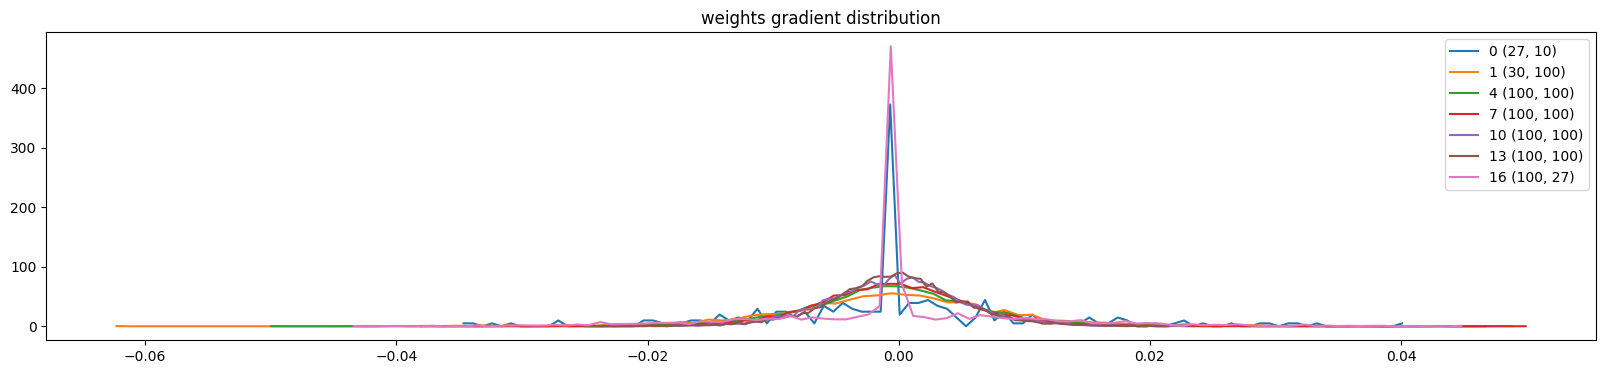

In [8]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

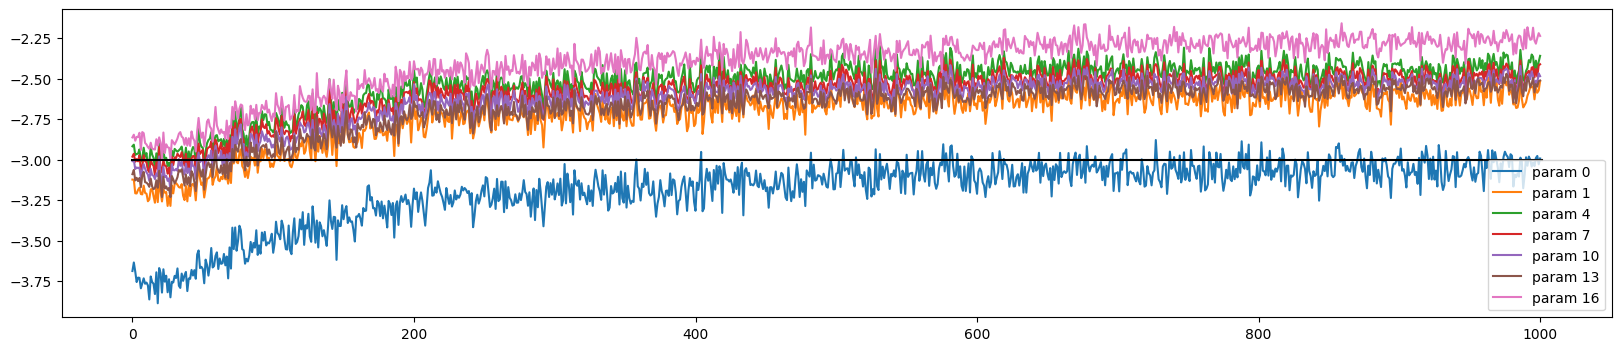

In [9]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);